# Experiment 3: Pathology Classification Impact

Evaluates how harmonization methods affect pathology classification performance (AUC, MCC) across all 30 hospitals using Leave-One-Site-Out cross-validation.

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /Users/chox/Documents/Studia/4_rok/ART/eeg-site-effects


In [2]:
import logging
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization.eeg_plots import plot_eeg_feature_overview
from src.visualization.shap_utils import compute_shap_from_pipeline, shap_to_mean_series

logging.basicConfig(level=logging.INFO, format='%(message)s')

RESULTS_PATH     = 'results/tables/04_paradox_analysis/exp02_pathology_clf/exp02_pathology_clf_results.csv'
PIPELINE_SAVE_DIR = 'models/04_paradox_analysis/exp02_pathology_clf_pipelines'
SHAP_DATA_SAVE_DIR = 'results/shap_data/04_paradox_analysis/exp02_pathology_clf'
FIGURES_DIR      = 'results/figures/04_paradox_analysis/exp02_pathology_clf'

METHODS = ['raw', 'sitewise', 'combat', 'neurocombat', 'covbat']

/Users/chox/Documents/Studia/4_rok/ART/eeg-site-effects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Analysis

In [3]:
results_df = pd.read_csv(RESULTS_PATH)

pivot = results_df.pivot_table(index='method', columns='hospital', values='auc', aggfunc='mean')
sort_idx = pivot.loc['raw'].values.argsort()[::-1]
hospitals_sorted = pivot.columns.values[sort_idx]

/var/folders/kb/3jqrfg_91312qsz97b4mj_p40000gn/T/ipykernel_63590/3153722101.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hospitals_sorted, rotation=90, fontsize=11)


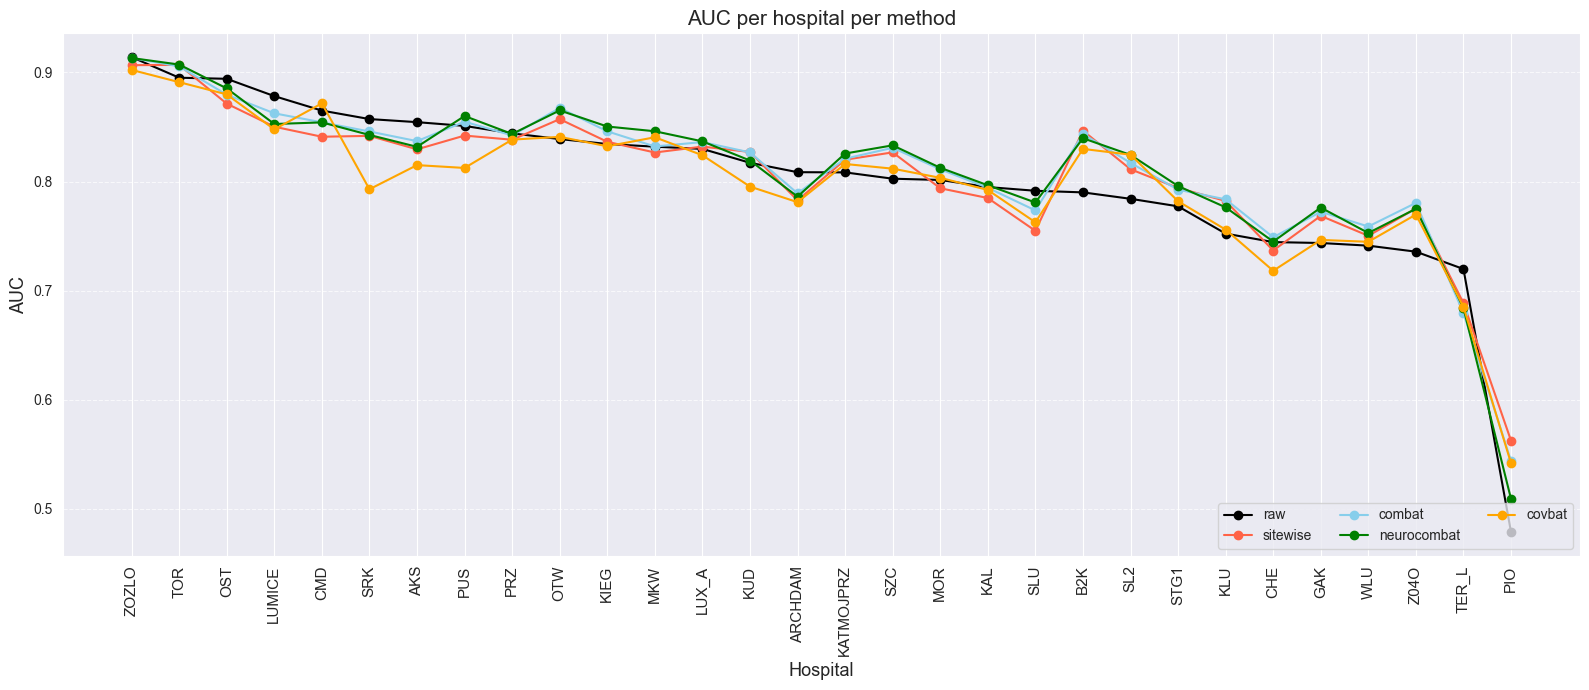

/var/folders/kb/3jqrfg_91312qsz97b4mj_p40000gn/T/ipykernel_63590/3153722101.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hospitals_sorted, rotation=90, fontsize=11)


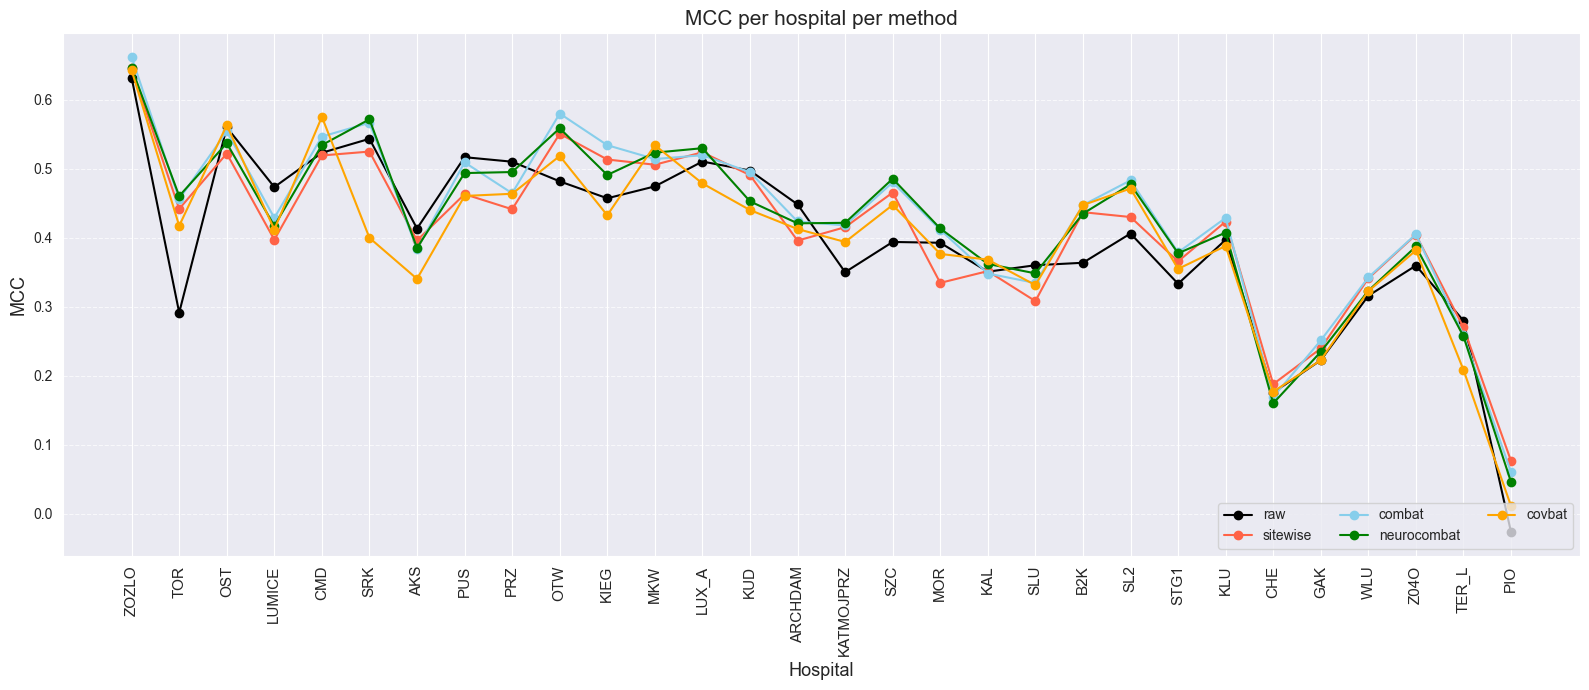

In [4]:
os.makedirs(FIGURES_DIR, exist_ok=True)

color_grid = ['black', 'tomato', 'skyblue', 'green', 'orange', 'purple', 'brown', 'cyan']

for metric in ['auc', 'mcc']:
    mean_df = results_df.pivot_table(index='method', columns='hospital', values=metric, aggfunc='mean')

    fig, ax = plt.subplots(figsize=(16, 7))
    for i, method in enumerate(METHODS):
        values = [mean_df.loc[method].get(h, float('nan')) for h in hospitals_sorted]
        ax.plot(hospitals_sorted, values, marker='o', linestyle='-',
                color=color_grid[i], label=method)

    ax.set_ylabel(metric.upper(), fontsize=13)
    ax.set_xlabel("Hospital", fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(loc='lower right', fontsize=10, ncol=3)
    ax.set_title(f"{metric.upper()} per hospital per method", fontsize=15)
    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/pathology_{metric}_per_hospital.png", dpi=150, bbox_inches='tight')
    plt.show()

## SHAP Analysis

In [ ]:
pipelines = {}
test_data = {}
for method in METHODS:
    pipelines[method] = {}
    test_data[method] = {}
    for hospital in hospitals_sorted:
        pipeline_path = os.path.join(PIPELINE_SAVE_DIR, f'{method}_{hospital}_pipeline.joblib')
        pipelines[method][hospital] = joblib.load(pipeline_path)

        data_path = os.path.join(SHAP_DATA_SAVE_DIR, f'{method}_{hospital}_test_data.parquet')
        test_data[method][hospital] = pd.read_parquet(data_path)

In [ ]:
shap_values = {}
X_shap = {}
for method in METHODS:
    shap_values[method] = {}
    X_shap[method] = {}
    for hospital in hospitals_sorted:
        X_test = test_data[method][hospital].drop(columns=['y_true'])
        shap_values[method][hospital], X_shap[method][hospital] = compute_shap_from_pipeline(
            pipelines[method][hospital], X_test
        )
        logging.info(f"SHAP done: {method} / {hospital}")

In [ ]:
os.makedirs(FIGURES_DIR, exist_ok=True)

for method in METHODS:
    mean_series_list = [shap_to_mean_series(shap_values[method][h]) for h in hospitals_sorted]
    shap_series = pd.concat(mean_series_list, axis=1).mean(axis=1)
    fig, axs = plot_eeg_feature_overview(features_series=shap_series, figure_title=f"Method: {method}")
    save_path = f"{FIGURES_DIR}/exp02_{method}_shap_overview.png"
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    logging.info(f"Saved: {save_path}")
    plt.close(fig)

In [ ]:
for method in METHODS:
    for hospital_id in hospitals_sorted:
        shap_series = shap_to_mean_series(shap_values[method][hospital_id])
        fig, axs = plot_eeg_feature_overview(
            features_series=shap_series,
            figure_title=f"Method: {method}, Hospital: {hospital_id}"
        )
        save_dir = f"{FIGURES_DIR}/{method}"
        os.makedirs(save_dir, exist_ok=True)
        save_path = f"{save_dir}/exp02_{method}_{hospital_id}_shap_overview.png"
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    logging.info(f"Per-hospital SHAP saved: {method}")